In [1]:
raid_path = '/raid/t2/TGN_adv'
sparsified_path = 'sparsified_data'
poisoned_path = 'poisoned_data' 

In [46]:
import os
import pandas as pd
import numpy as np

In [ ]:
def append_suffix_to_path(base_path, which_pth, suffix):
    new_basename = f"{which_pth}_{suffix}"
    return os.path.join(base_path, new_basename)


raid_path_02 = append_suffix_to_path(raid_path, sparsified_path, '0.2')
sparsified_path_04 = append_suffix_to_path(raid_path, sparsified_path, '0.4')

print(raid_path_02)       # /raid/t2/TGN_adv/sparsified_data_0.2
print(sparsified_path_04) # /raid/t2/TGN_adv/sparsified_data_0.4

/raid/t2/TGN_adv/sparsified_data_0.2
/raid/t2/TGN_adv/sparsified_data_0.4


In [126]:
knowledge = 0.4
dataset_name = 'uci'
clean_file = f = f'ml_{dataset_name}.csv'

knowledge_abl_path = append_suffix_to_path(raid_path, sparsified_path, knowledge)
clean_file_path = os.path.join(knowledge_abl_path, dataset_name, clean_file)

# print(clean_file_path)

clean_df = pd.read_csv(clean_file_path)
clean_df.drop(['Unnamed: 0'], axis=1, inplace=True)
clean_df.head()

,u,i,ts,label,idx
0,1,2,0,0,1
1,3,4,114878,0,2
2,5,2,373430,0,3
3,6,7,398658,0,4
4,8,7,398795,0,5


In [127]:
ss_type = 'ts_tpr_remove_cosine'

sprs_file = f"{dataset_name}_{ss_type}_sparsified_0.7.csv"
sprs_file_path = os.path.join(knowledge_abl_path, dataset_name, ss_type, sprs_file)

print(sprs_file_path)
# assert '/raid/t2/TGN_adv/sparsified_data_0.2/wikipedia/ts_tpr_remove_cosine/wikipedia_ts_tpr_remove_cosine_sparsified_0.7.csv' == sprs_file_path, print(sprs_file_path)
sprs_df = pd.read_csv(sprs_file_path)
sprs_df.drop(['Unnamed: 0'], axis=1, inplace=True)
sprs_df.head()

/raid/t2/TGN_adv/sparsified_data_0.4/uci/ts_tpr_remove_cosine/uci_ts_tpr_remove_cosine_sparsified_0.7.csv


,u,i,ts,label,idx
0,1,2,0,0,1
1,3,4,114878,0,2
2,5,2,373430,0,3
3,6,7,398658,0,4
4,8,7,398795,0,5


In [128]:
len(clean_df), len(sprs_df)

(59835, 16780)

In [129]:
22047 / (157474*0.2)

0.7000203208148646

In [130]:
val_ratio = test_ratio = 0.3

val_time, test_time = list(np.quantile(clean_df.ts, [(1 - val_ratio - test_ratio), (1 - test_ratio)]))

orig_df = clean_df[clean_df['ts'] < val_time]
len(orig_df), len(sprs_df) / len(orig_df)

orig_df.head()

,u,i,ts,label,idx
0,1,2,0,0,1
1,3,4,114878,0,2
2,5,2,373430,0,3
3,6,7,398658,0,4
4,8,7,398795,0,5


In [131]:
len(orig_df), len(sprs_df)

(23934, 16780)

In [132]:
all_edges = set(tuple(x) for x in orig_df[['u', 'i', 'ts']].values)
sprs_edges = set(tuple(x) for x in sprs_df[['u', 'i', 'ts']].values)

print(len(all_edges), len(sprs_edges), (len(all_edges) - len(sprs_edges))/len(all_edges))

removed_edge_sets = set(all_edges) - set(sprs_edges)

print(len(removed_edge_sets) / len(all_edges))

23918 16775 0.2986453716865959
0.2986453716865959


In [125]:
K_02_df = pd.DataFrame(removed_edge_sets, columns=['u', 'i', 'ts'])
K_02_df.head()

,u,i,ts
0,698,184,1666157
1,561,254,1704825
2,48,683,1779127
3,553,456,1424667
4,747,761,1789600


In [133]:
K_04_df = pd.DataFrame(removed_edge_sets, columns=['u', 'i', 'ts'])
K_04_df.head()

,u,i,ts
0,448,299,2138598
1,428,400,2369605
2,194,482,2716007
3,325,1072,2544940
4,19,991,2730449


In [134]:
len(K_04_df['ts']), len(K_02_df['ts'])

(7143, 3574)

In [135]:
len(set(K_04_df['ts']) - set(K_02_df['ts']))  # 18213
len(set(K_04_df['ts']).intersection(set(K_02_df['ts'])))

45

In [45]:
import pandas as pd
import os
from itertools import combinations

def append_suffix_to_path(base_path, which_pth, suffix):
    new_basename = f"{which_pth}_{suffix}"
    return os.path.join(base_path, new_basename)

def load_removed_edges(knowledge, dataset_name, ss_type):
    knowledge_abl_path = append_suffix_to_path(raid_path, sparsified_path, knowledge)
    sprs_file = f"{dataset_name}_{ss_type}_sparsified_0.7.csv"
    sprs_file_path = os.path.join(knowledge_abl_path, dataset_name, ss_type, sprs_file)
    
    df = pd.read_csv(sprs_file_path)
    df.drop(['Unnamed: 0'], axis=1, inplace=True)
    
    # Each edge is a (u, v, t) tuple
    return set(tuple(x) for x in df[['u', 'i', 'ts']].values)

# Define your parameters
raid_path = '/raid/t2/TGN_adv'
sparsified_path = 'sparsified_data'
dataset_name = 'wikipedia'
ss_type = 'ts_tpr_remove_cosine'
knowledge_levels = [0.2, 0.4, 0.8]

# Load all removed edge sets
edge_sets = {
    k: load_removed_edges(k, dataset_name, ss_type) for k in knowledge_levels
}

# Compute pairwise overlaps (Jaccard similarity)
for k1, k2 in combinations(knowledge_levels, 2):
    e1 = edge_sets[k1]
    e2 = edge_sets[k2]
    common = e1 & e2
    union = e1 | e2
    jaccard = len(common) / len(union) if union else 0
    print(f"Overlap ({k1}, {k2}):")
    print(f"  ➤ Common edges: {len(common)}")
    print(f"  ➤ Jaccard similarity: {jaccard:.4f}")
    print()


Overlap (0.2, 0.4):
  ➤ Common edges: 22047
  ➤ Jaccard similarity: 0.4993

Overlap (0.2, 0.8):
  ➤ Common edges: 22047
  ➤ Jaccard similarity: 0.2496

Overlap (0.4, 0.8):
  ➤ Common edges: 44158
  ➤ Jaccard similarity: 0.4999



In [ ]:
val_ratio = test_ratio = 0.3

val_time, test_time = list(np.quantile(clean_df.ts, [(1 - val_ratio - test_ratio), (1 - test_ratio)]))

orig_df = clean_df[clean_df['ts'] < val_time]
len(orig_df)

62990

In [73]:
all_edges = set(tuple(x) for x in orig_df[['u', 'i', 'ts']].values)
sprs_edges = set(tuple(x) for x in sprs_df[['u', 'i', 'ts']].values)


len(all_edges), len(sprs_edges), (len(all_edges) - len(sprs_edges))/62990

(62990, 44158, 0.2989680901730433)

In [82]:
removed_df = pd.DataFrame(set(all_edges) - set(sprs_edges), columns=['u', 'i', 'ts']
                          )
removed_df.sort_values(by=['ts'], ascending=True, inplace=True)
removed_df.head()


,u,i,ts
9697,2892.0,8888.0,604874.0
16584,2893.0,8751.0,605176.0
2709,2894.0,8339.0,605501.0
3935,2895.0,8532.0,605514.0
16174,2896.0,8888.0,605590.0


In [141]:
import pandas as pd
import os
from itertools import combinations

def append_suffix_to_path(base_path, which_pth, suffix):
    new_basename = f"{which_pth}_{suffix}"
    return os.path.join(base_path, new_basename)

def load_sparsified_edges(knowledge, dataset_name, ss_type, base_path, sparsified_dir):
    path = append_suffix_to_path(base_path, sparsified_dir, knowledge)
    file_name = f"{dataset_name}_{ss_type}_sparsified_0.7.csv"
    full_path = os.path.join(path, dataset_name, ss_type, file_name)
    
    df = pd.read_csv(full_path)
    df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
    return set(tuple(x) for x in df[['u', 'i', 'ts']].values)

def check_sparsified_overlap(knowledge_levels, dataset_name, ss_type, base_path, sparsified_dir):
    edge_sets = {
        k: load_sparsified_edges(k, dataset_name, ss_type, base_path, sparsified_dir)
        for k in knowledge_levels
    }

    for k1, k2 in combinations(knowledge_levels, 2):
        e1, e2 = edge_sets[k1], edge_sets[k2]
        print(f'{k1}: {len(e1)}; {k2}: {len(e2)}')
        common = e1 & e2
        union = e1 | e2
        
        print(len(union))
        jaccard = len(common) / len(union) if union else 0
        is_subset = e1.issubset(e2)

        print(f"Overlap between knowledge={k1} and {k2}:")
        print(f"  ➤ Common edges: {len(common)}")
        print(f"  ➤ Jaccard similarity: {jaccard:.4f}")
        print(f"  ➤ Is {k1} ⊆ {k2}? {'✅ YES' if is_subset else '❌ NO'}\n")
# === Usage ===
raid_path = '/raid/t2/TGN_adv'
sparsified_path = 'sparsified_data'
dataset_name = 'wikipedia'
ss_type = 'ts_tpr_remove_cosine'
knowledge_levels = [0.2, 0.4, 0.8]

check_sparsified_overlap(
    knowledge_levels, dataset_name, ss_type, raid_path, sparsified_path
)


0.2: 22047; 0.4: 44158
44158
Overlap between knowledge=0.2 and 0.4:
  ➤ Common edges: 22047
  ➤ Jaccard similarity: 0.4993
  ➤ Is 0.2 ⊆ 0.4? ✅ YES

0.2: 22047; 0.8: 88326
88326
Overlap between knowledge=0.2 and 0.8:
  ➤ Common edges: 22047
  ➤ Jaccard similarity: 0.2496
  ➤ Is 0.2 ⊆ 0.8? ✅ YES

0.4: 44158; 0.8: 88326
88326
Overlap between knowledge=0.4 and 0.8:
  ➤ Common edges: 44158
  ➤ Jaccard similarity: 0.4999
  ➤ Is 0.4 ⊆ 0.8? ✅ YES



Overlap between knowledge=0.2 and 0.4:
  ➤ |0.2| = 22047; |0.4| = 44158
  ➤ Common = 22047
  ➤ Jaccard = 0.4993
  ➤ Is 0.2 ⊆ 0.4? ✅

Overlap between knowledge=0.2 and 0.8:
  ➤ |0.2| = 22047; |0.8| = 88326
  ➤ Common = 22047
  ➤ Jaccard = 0.2496
  ➤ Is 0.2 ⊆ 0.8? ✅

Overlap between knowledge=0.4 and 0.8:
  ➤ |0.4| = 44158; |0.8| = 88326
  ➤ Common = 44158
  ➤ Jaccard = 0.4999
  ➤ Is 0.4 ⊆ 0.8? ✅



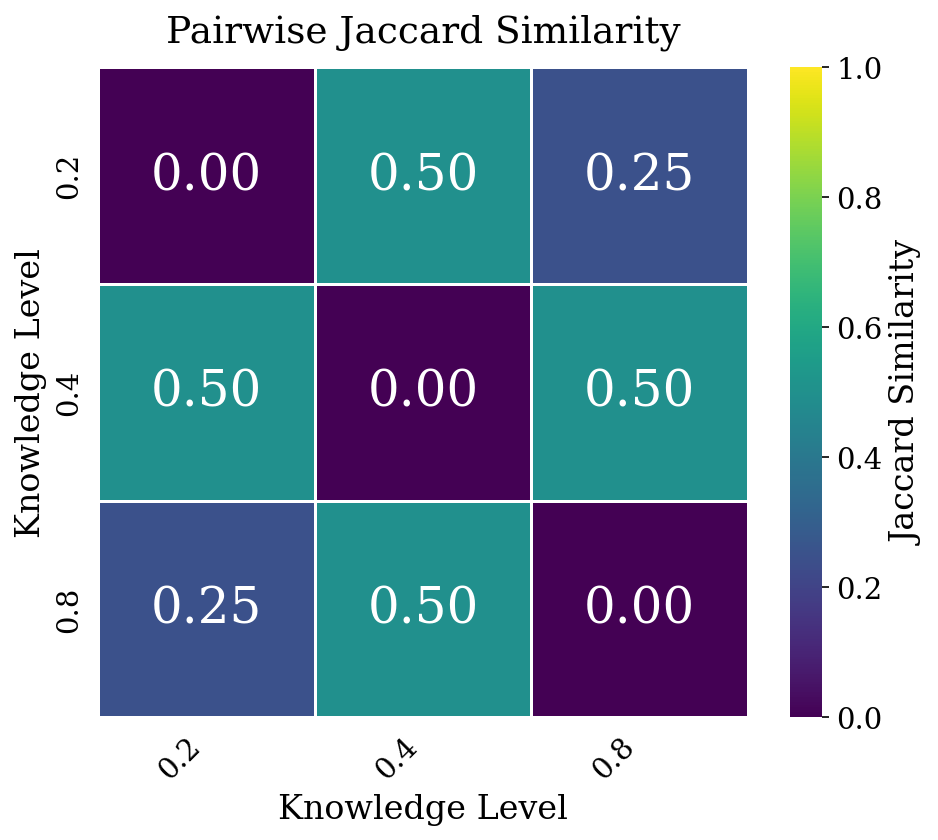

In [6]:
import pandas as pd
import os
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# === Matplotlib AAAI-style ===
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["dejavu serif"],
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.dpi": 150,
    "axes.grid": False
})

def append_suffix_to_path(base_path, which_pth, suffix):
    new_basename = f"{which_pth}_{suffix}"
    return os.path.join(base_path, new_basename)

def load_sparsified_edges(knowledge, dataset_name, ss_type, base_path, sparsified_dir):
    path = append_suffix_to_path(base_path, sparsified_dir, knowledge)
    file_name = f"{dataset_name}_{ss_type}_sparsified_0.7.csv"
    full_path = os.path.join(path, dataset_name, ss_type, file_name)
    
    df = pd.read_csv(full_path)
    df.drop(columns=['Unnamed: 0'], inplace=True, errors='ignore')
    return set(tuple(x) for x in df[['u', 'i', 'ts']].values)

def plot_jaccard_matrix_old(jaccard_dict, knowledge_levels):
    n = len(knowledge_levels)
    matrix = np.zeros((n, n))
    for (k1, k2), jacc in jaccard_dict.items():
        i, j = knowledge_levels.index(k1), knowledge_levels.index(k2)
        matrix[i, j] = matrix[j, i] = jacc

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(matrix, cmap='Blues', vmin=0, vmax=1)

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(knowledge_levels)
    ax.set_yticklabels(knowledge_levels)

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center", color="black")

    ax.set_title("Pairwise Jaccard Similarity")
    ax.set_xlabel("Knowledge Level")
    ax.set_ylabel("Knowledge Level")

    cbar = fig.colorbar(im, ax=ax, shrink=0.8, label='Jaccard Similarity')
    plt.tight_layout()
    plt.savefig("knowledge_abl_jaccard_matrix.pdf", bbox_inches='tight')
    plt.show()

def plot_jaccard_matrix(jaccard_dict, knowledge_levels):
    n = len(knowledge_levels)
    matrix = np.zeros((n, n))
    for (k1, k2), jacc in jaccard_dict.items():
        i, j = knowledge_levels.index(k1), knowledge_levels.index(k2)
        matrix[i, j] = matrix[j, i] = jacc

    sns.set_style("white")
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["DejaVu Serif"],
        "axes.titlesize": 18,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "text.color": "black",
        "axes.labelcolor": "black",
        "xtick.color": "black",
        "ytick.color": "black"
    })

    fig, ax = plt.subplots(figsize=(6.5, 5.5), facecolor='white')
    sns.heatmap(
        matrix,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        vmin=0,
        vmax=1,
        xticklabels=knowledge_levels,
        yticklabels=knowledge_levels,
        cbar_kws={"label": "Jaccard Similarity"},
        square=True,
        linewidths=0.5,
        linecolor='white',
        annot_kws={"fontsize": 24, "color": "white"},
        ax=ax
    )

    ax.set_title("Pairwise Jaccard Similarity", pad=12, color="black")
    ax.set_xlabel("Knowledge Level", color="black")
    ax.set_ylabel("Knowledge Level", color="black")
    plt.xticks(rotation=45, ha='right', color="black")
    plt.yticks(color="black")

    plt.tight_layout()
    plt.savefig("knowledge_abl_jaccard_matrix.pdf", bbox_inches='tight', facecolor='white')
    plt.show()

# === Example Usage ===
raid_path = '/raid/t2/TGN_adv'
sparsified_path = 'sparsified_data'
dataset_name = 'wikipedia'
ss_type = 'ts_tpr_remove_cosine'
knowledge_levels = [0.2, 0.4, 0.8]

check_sparsified_overlap(
    knowledge_levels, dataset_name, ss_type, raid_path, sparsified_path
)
